In [19]:
import pandas as pd
from pathlib import Path
file_name = 'Front_EE-1_1_3000x_rings_coords.csv'
# csv_file = Path('/Users/rishabhkumar/spiral-chirals/vf_exports/Front_EE-1_1_3000x_rings_coords.csv')
csv_file = Path.cwd() / 'vf_exports' / file_name
with open(csv_file, 'r') as f:
    df = pd.read_csv(f)

print(df.head())
# remove the last row 
df = df.iloc[:-1]

  Ring     Coordinate  Angle (α′)        Pattern
0    1   (7.00, 0.00)      -26.09      Clockwise
1    1  (0.00, -7.00)       58.86  Anticlockwise
2    1  (-7.00, 0.00)      -31.99      Clockwise
3    1   (0.00, 7.00)       73.30  Anticlockwise
4    2  (43.00, 0.00)      -11.86      Clockwise


In [20]:
# helper functions 
import ast

def parse_coord(s):
    if isinstance(s, (list, tuple, np.ndarray)):
        return list(s)
    if not isinstance(s, str):
        return [np.nan, np.nan]
    s = s.strip()
    try:
        val = ast.literal_eval(s)          # handles "(7.00, 0.00)" or "[7.00, 0.00]"
        return list(val)
    except Exception:
        parts = [p.strip() for p in s.strip("()[]").split(",")]
        try:
            return [float(parts[0]), float(parts[1])]
        except Exception:
            return [np.nan, np.nan]

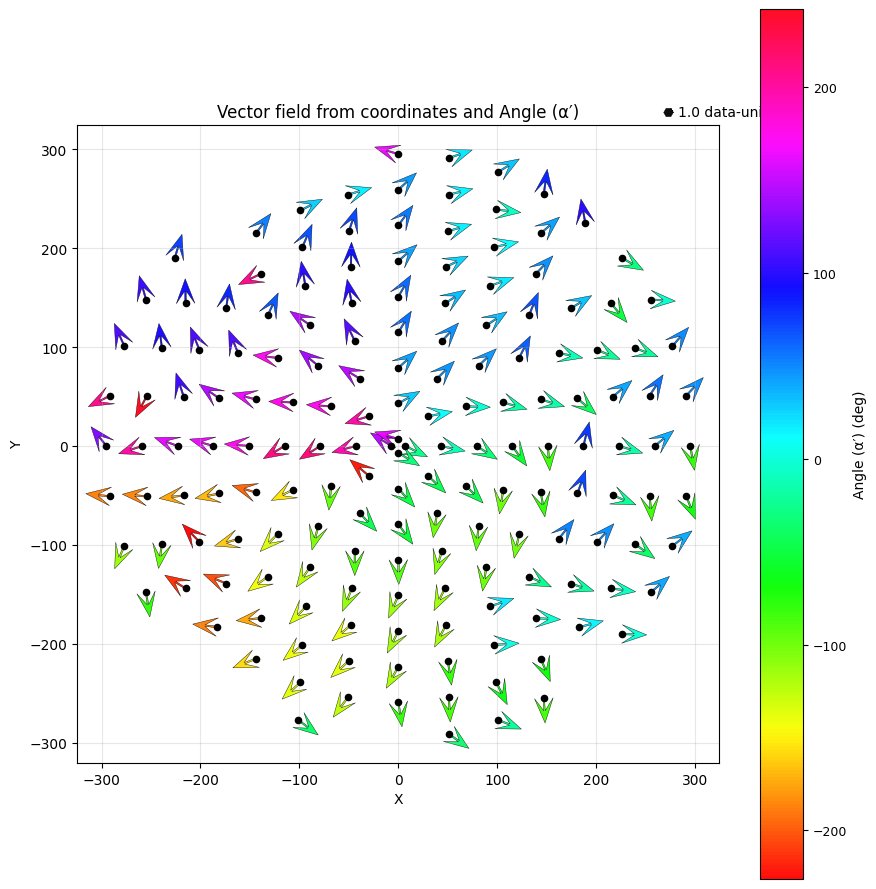

In [21]:
import matplotlib.pyplot as plt
import numpy as np
# Extract angles and filter valid data
angles_deg = df['Angle (α′)'].values 

# df['Coordinate'] = df['Coordinate'].apply(lambda x: np.array(x))    
coordinates = df['Coordinate'].apply(parse_coord).tolist()
# Find global theta from the coordinates 



# For these angles and coordinates, plot a vector field
X = [coord[0] for coord in coordinates]
Y = [coord[1] for coord in coordinates]
r = np.sqrt(np.array(X)**2 + np.array(Y)**2)
theta = np.arctan2(
    np.array(Y),
    np.array(X)
)
phi = angles_deg + np.degrees(theta)
phi_rad = np.deg2rad(phi)
U_plot = np.cos(phi_rad)
V_plot = np.sin(phi_rad)
# Compute a reasonable scale factor for the quiver key
scale_factor = np.round(np.percentile(np.sqrt(U_plot**2 + V_plot**2), 75), 1)
if scale_factor == 0:
    scale_factor = 1.0
# Create the plot
plt.figure(figsize=(9, 9))
magnitude_scale = 25.0
U_plot_scaled = magnitude_scale * U_plot
V_plot_scaled = magnitude_scale * V_plot
q = plt.quiver(
    X, Y, U_plot_scaled, V_plot_scaled, phi,
    angles='xy', scale_units='xy', scale=1, cmap='hsv',
    width=0.015,
    headwidth=12,
    headlength=16,
    headaxislength=8,
    alpha=0.95, edgecolor='k', linewidth=0.3
)
plt.scatter(X, Y, c='k', s=20, zorder=3)
plt.gca().set_aspect('equal', 'box')
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Vector field from coordinates and Angle (α′)')
cbar = plt.colorbar(q, label='Angle (α′) (deg)')
cbar.ax.tick_params(labelsize=9)
plt.quiverkey(q, X=0.92, Y=1.02, U=scale_factor,
              label=f'{scale_factor} data-units', labelpos='E',
              fontproperties={'size':10})
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('vector_field_plot.svg', dpi=300)
plt.show()

Commented markdown
<!-- ## Weighted Least Squares Fitting of Angle vs Radius

As shown in the previous vector field fitting experiment, we see that the residuals show ill-fitting vector fields. A possible explanation of this phenomenon is the the heteroskedasticity problem with the statistically equivalent problem. In this notebook, we study the statistically equivalent problem to the least squares minimization and upon fixing the optimization problem, we can get a statistically sound problem for regression. 

### Vector Field Regression
Suppose we measure a noisy vector field in $\{(x_i, y_i) \}_{i = 1}^N \subset \mathbb R^2$ , 
$$
W_i = F(x_i, y_i) + \varepsilon_i
$$

where $\varepsilon_i \sim^{iid} \mathcal N(0, \sigma^2)$ -->

# **Statistical Formulation of the Vector Field Fitting Problem**

## **1. Parametric Spiral Vector Field**

We assume a parametric potential function  
$$
V_\theta(r,\phi) = A\,g_p(r) - b\,\phi,
$$
where  
$$
g_p(r) =
\begin{cases}
\ln r, & p = 0, \\[6pt]
\dfrac{r^p}{p}, & p \neq 0.
\end{cases}
$$
where $r$ is the radial distance, and $\phi$ is the azimuthal angle. 

The induced vector field is the gradient
$$
F_\theta(x,y) = \nabla V_\theta(x,y).
$$

In polar coordinates,
$$
F_\theta(r,\phi)
=
\left(
A g_p'(r),\;
-\frac{b}{r}
\right).
$$

The magnitude of the field is
$$
\rho(r)
=
\big\| F_\theta(r,\phi) \big\|
=
\sqrt{
A^2 \big(g_p'(r)\big)^2
+
\frac{b^2}{r^2}
}.
$$

---

## **2. Noisy Observations**

At spatial points  
$$
Z_i = (x_i, y_i), \quad i = 1,\dots,n,
$$

we observe noisy vector values:
$$
W_i = F_{\theta_0}(Z_i) + \varepsilon_i,
$$
where the noise is isotropic,
$$
\varepsilon_i \sim N(0,\,\sigma^2 I_2).
$$

The observed direction angle is
$$
\hat{\alpha}_i = \operatorname{atan2}(W_{i,2},\; W_{i,1}).
$$

---

## **3. Noise Structure in Angular Coordinates**

Linearizing the Cartesian→polar transformation yields
$$
\hat{\alpha}_i
=
\alpha_{\theta_0}(Z_i)
+
\delta\alpha_i,
$$
with heteroskedastic variance
$$
\operatorname{Var}(\delta\alpha_i)
=
\frac{\sigma^2}{\rho(Z_i)^2}.
$$

Thus angle estimates are noisy in regions where the field magnitude $\rho(r)$ is small.

---

## **4. Statistical Objective (Weighted Least Squares)**

Given observed angles $\hat{\alpha}_i$, estimate $\theta$ by minimizing the discrepancy between  
$\hat{\alpha}_i$ and the predicted angle $\alpha_\theta(Z_i)$.

Under the Gaussian angular noise model, the negative log-likelihood (up to constants) is:
$$
L(\theta)
=
\sum_{i=1}^n 
\rho(Z_i)^2
\big(
\hat{\alpha}_i - \alpha_\theta(Z_i)
\big)^2.
$$

Because angles lie on the circle, we may instead use a wrapped loss:
$$
L(\theta)
=
\sum_{i=1}^n 
\rho(Z_i)^2
\sin^2
\!\big(
\hat{\alpha}_i - \alpha_\theta(Z_i)
\big).
$$

Both losses are statistically valid; they differ only at higher-order terms when the angle errors are small.

---

## **5. Summary**

- Noisy observations follow  
  $$
  W_i = F_{\theta_0}(Z_i) + \varepsilon_i.
  $$

- Angle noise is heteroskedastic:  
  $$
  \operatorname{Var}(\hat{\alpha}_i) = \frac{\sigma^2}{\rho(Z_i)^2}.
  $$

- The statistically correct estimator of $\theta$ is **weighted least squares**:
  $$
  \hat{\theta}
  =
  \arg\min_\theta
  \sum_i
  \rho(Z_i)^2\,
  d\big(
    \hat{\alpha}_i,\,
    \alpha_\theta(Z_i)
  \big),
  $$
  where $d(x,y)$ is either $(x-y)^2$ or $\sin^2(x-y)$.

This fully specifies the statistically rigorous formulation of the **spiral vector field regression problem**.


# **Spiral Vector Fields: Summary Table**

| **Spiral Type** | **$g_p'(r)$** | **Vector Field** $F(r,\phi)$ | **Magnitude** $\rho(r)$ | **Weight** $w(r)=\rho(r)^2$ | **Weighted LS Objective** $L(\theta)$ |
|-----------------|---------------|-------------------------------|--------------------------|------------------------------|----------------------------------------|
| **Log Spiral** | $$\frac{1}{r}$$ | $$F_{\text{log}}(r,\phi)=\left(\frac{A}{r},\;-\frac{b}{r}\right)$$ | $$\rho_{\text{log}}(r)=\frac{\sqrt{A^2+b^2}}{r}$$ | $$w_{\text{log}}(r)=\frac{A^2+b^2}{r^2}$$ | $$L_{\text{log}}(\theta)=\sum_i \frac{A^2+b^2}{r_i^2}\ d^2(\hat{\alpha}_i,\alpha_\theta) = 1/b^2\sum_i \frac{1/k^2 + 1}{r_i^2}\ d^2(\hat{\alpha}_i,\alpha_\theta)  \\ = L_{\log}(k)$$ |
| **Archimedean Spiral** | $$1$$ | $$F_{\text{arch}}(r,\phi)=\left(A,\;-\frac{b}{r}\right)$$ | $$\rho_{\text{arch}}(r)=\sqrt{A^2+\frac{b^2}{r^2}}$$ | $$w_{\text{arch}}(r)=A^2+\frac{b^2}{r^2}$$ | $$L_{\text{arch}}(\theta)=\sum_i \left(A^2+\frac{b^2}{r_i^2}\right)\ d^2(\hat{\alpha}_i,\alpha_\theta)$$ |
| **Fermat Spiral** | $$r$$ | $$F_{\text{fermat}}(r,\phi)=\left(A r,\;-\frac{b}{r}\right)$$ | $$\rho_{\text{fermat}}(r)=\sqrt{A^2 r^2+\frac{b^2}{r^2}}$$ | $$w_{\text{fermat}}(r)=A^2 r^2+\frac{b^2}{r^2}$$ | $$L_{\text{fermat}}(\theta)=\sum_i \left(A^2 r_i^2+\frac{b^2}{r_i^2}\right)\ d^2(\hat{\alpha}_i,\alpha_\theta)$$ |

---

For log spirals $r = a \exp (k \theta)$, we can set $A$ and $b$ in the above model such that $A / b = 1 / k$. Parameter $a$ acts as a relative constant, controlling the level set of the potential curves, hence setting $A/b = 1/k$. 

For Archimedean spiral vector fields, $r = b \theta$, we set $A = 1$, $b=b$, with $p = 1$ for the parameterized function $g_p(\cdot)$.

For Fermat spirals, $r^2 = a^2 \theta$, we set $A = 2$, $b = a^2$, with $p = 2$ for the parameterized function $g_p(\cdot)$. 


Optimized k (least squares): 16.0585 degrees
Optimized k (sin squared): 10.3192 degrees
  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 213.9853981308204
        x: [ 1.606e+01]
      nit: 11
      jac: [ 5.722e-06]
 hess_inv: [[ 4.911e+00]]
     nfev: 24
     njev: 12
  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.04884440807245794
        x: [ 1.032e+01]
      nit: 11
      jac: [-2.723e-06]
 hess_inv: [[ 3.173e+04]]
     nfev: 28
     njev: 14


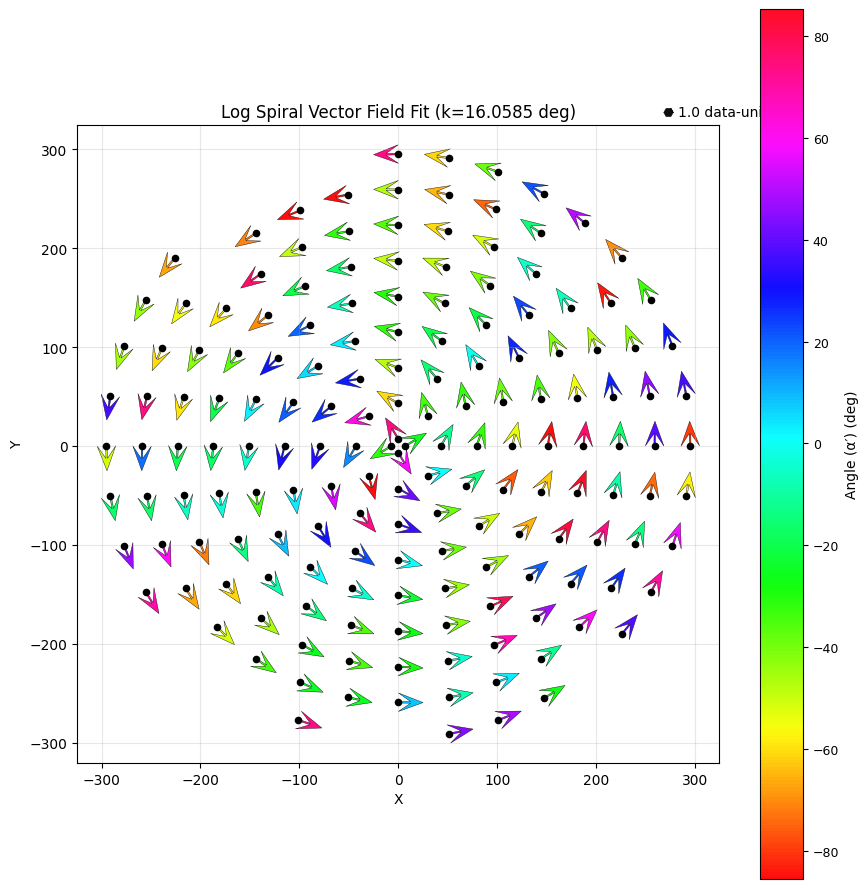

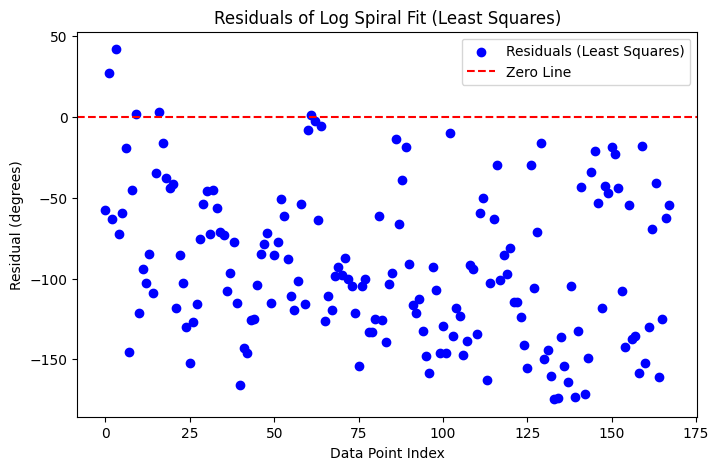

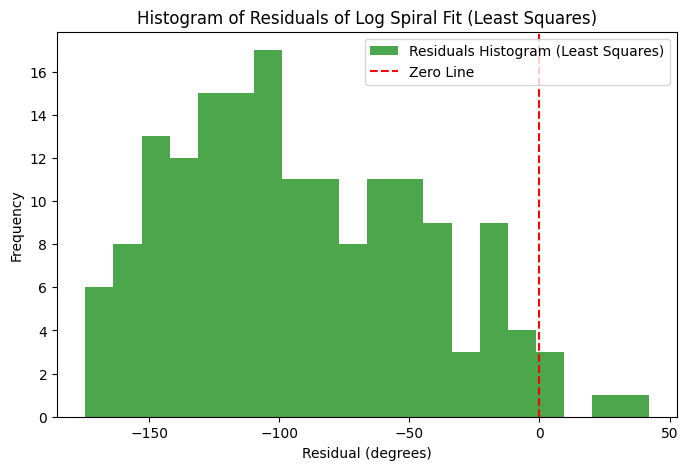

In [22]:
## Solve the least squares problem to fit spirals
from scipy.optimize import minimize
def objective_log_spiral(k, angles, r, scaling = True): # One only observes angles and $r$
    if scaling:
        residuals = np.sqrt(1/k**2 + 1)/r * (angles - k)
    else:
        residuals = angles - k
    return np.sum(residuals**2)

def objective_log_spiral_sin(k, angles, r, scaling = True):
    if scaling == True: 
        residuals = np.sqrt(1/k**2 + 1)/r * np.sin(np.deg2rad(angles - k))
    else:
        residuals = np.sin(np.deg2rad(angles - k))
    return np.sum(residuals**2)

# Initial guess for k
k0 = 2.0
# Optimize using the first objective function
result1 = minimize(objective_log_spiral, k0, args=(angles_deg, r))
k_opt1 = result1.x[0]
# Optimize using the second objective function
result2 = minimize(objective_log_spiral_sin, k0, args=(angles_deg, r))
k_opt2 = result2.x[0]

print(f"Optimized k (least squares): {k_opt1:.4f} degrees")
print(f"Optimized k (sin squared): {k_opt2:.4f} degrees")
print(result1)
print(result2)

# ------- PLOTTING THE FITTED VECTOR FIELD -------
# Plotting log spiral vector field with above parameters (k_opt1 and k_opt2)
def log_spiral_vector_field(x, y, k):
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    alpha_prime = k * np.log(r + 1e-8)  # add small value to avoid log(0)
    phi = theta + np.deg2rad(alpha_prime)
    Vx = np.cos(phi)
    Vy = np.sin(phi)
    return Vx, Vy

Vx1, Vy1 = log_spiral_vector_field(np.array(X), np.array(Y), k_opt1)
Vx2, Vy2 = log_spiral_vector_field(np.array(X), np.array(Y), k_opt2)
# Plotting
plt.figure(figsize=(9, 9))
magnitude_scale = 25.0
U1_scaled = magnitude_scale * Vx1
V1_scaled = magnitude_scale * Vy1
U2_scaled = magnitude_scale * Vx2
V2_scaled = magnitude_scale * Vy2

q1 = plt.quiver(
    X, Y, U1_scaled, V1_scaled, angles_deg,
    angles='xy', scale_units='xy', scale=1, cmap='hsv',
    width=0.015,
    headwidth=12,
    headlength=16,
    headaxislength=8,
    alpha=0.95, edgecolor='k', linewidth=0.3
)

plt.scatter(X, Y, c='k', s=20, zorder=3)
plt.gca().set_aspect('equal', 'box')
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Log Spiral Vector Field Fit (k={k_opt1:.4f} deg)')
cbar = plt.colorbar(q1, label='Angle (α′) (deg)')
cbar.ax.tick_params(labelsize=9)
plt.quiverkey(q1, X=0.92, Y=1.02, U=scale_factor,
              label=f'{scale_factor} data-units', labelpos='E',
              fontproperties={'size':10})
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('log_spiral_vector_field_fit.svg', dpi=300)
plt.show()

## Plot residuals 
predicted_angles = k_opt1 * np.log(r + 1e-8)
residuals1 = angles_deg - predicted_angles

plt.figure(figsize=(8, 5))
plt.scatter(range(len(residuals1)), residuals1, color='blue', label='Residuals (Least Squares)')
plt.axhline(0, color='red', linestyle='--', label='Zero Line')
plt.xlabel('Data Point Index')
plt.ylabel('Residual (degrees)')
plt.title('Residuals of Log Spiral Fit (Least Squares)')
plt.legend()

plt.figure(figsize=(8, 5))
plt.hist(residuals1, bins=20, color='green', alpha=0.7, label='Residuals Histogram (Least Squares)')
plt.axvline(0, color='red', linestyle='--', label='Zero Line')
plt.xlabel('Residual (degrees)')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals of Log Spiral Fit (Least Squares)')
plt.legend()
plt.show()

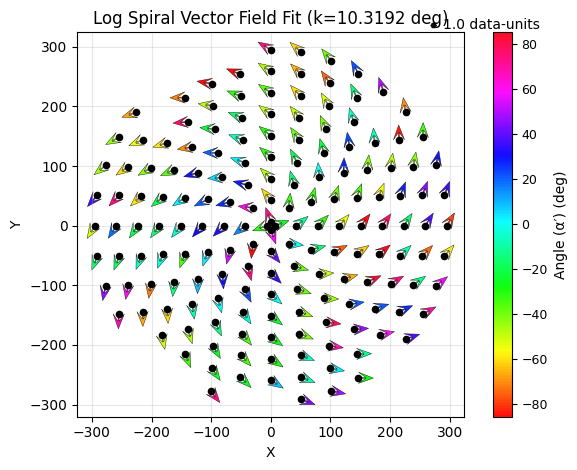

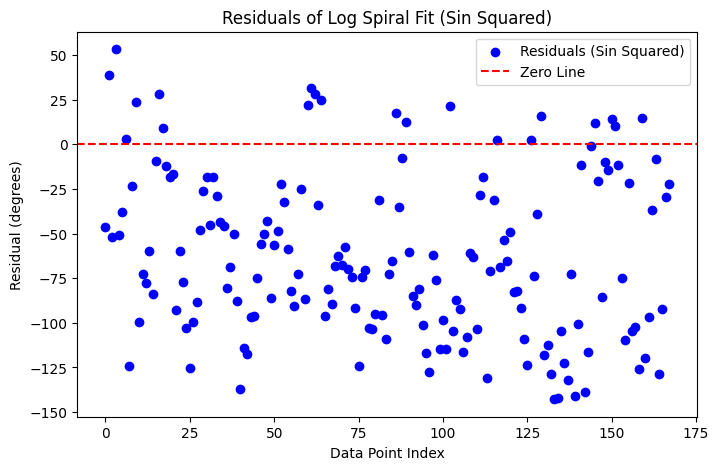

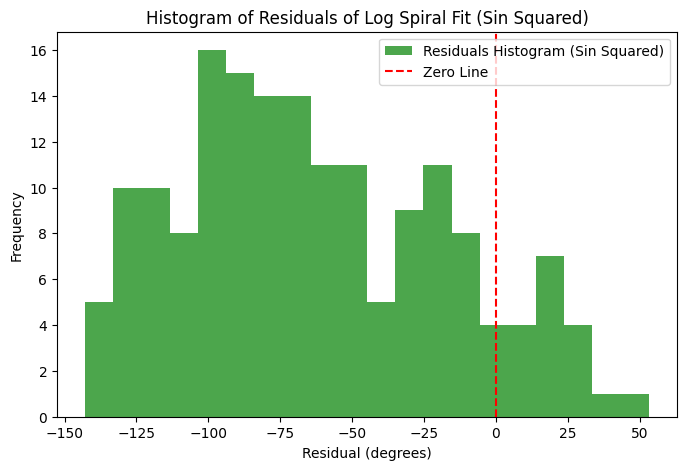

In [23]:
q2 = plt.quiver(
    X, Y, U2_scaled, V2_scaled, angles_deg,
    angles='xy', scale_units='xy', scale=1, cmap='hsv',
    width=0.015,
    headwidth=12,
    headlength=16,
    headaxislength=8,
    alpha=0.95, edgecolor='k', linewidth=0.3
)

plt.scatter(X, Y, c='k', s=20, zorder=3)
plt.gca().set_aspect('equal', 'box')
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Log Spiral Vector Field Fit (k={k_opt2:.4f} deg)')
cbar = plt.colorbar(q2, label='Angle (α′) (deg)')
cbar.ax.tick_params(labelsize=9)
plt.quiverkey(q2, X=0.92, Y=1.02, U=scale_factor,
              label=f'{scale_factor} data-units', labelpos='E',
              fontproperties={'size':10})
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('log_spiral_vector_field_fit_sin.svg', dpi=300)
plt.show()

## Plot residuals
residuals2 = angles_deg - (k_opt2 * np.log(r + 1e-8))
plt.figure(figsize=(8, 5))
plt.scatter(range(len(residuals2)), residuals2, color='blue', label='Residuals (Sin Squared)')
plt.axhline(0, color='red', linestyle='--', label='Zero Line')
plt.xlabel('Data Point Index')
plt.ylabel('Residual (degrees)')
plt.title('Residuals of Log Spiral Fit (Sin Squared)')
plt.legend()
plt.figure(figsize=(8, 5))
plt.hist(residuals2, bins=20, color='green', alpha=0.7, label='Residuals Histogram (Sin Squared)')
plt.axvline(0, color='red', linestyle='--', label='Zero Line')
plt.xlabel('Residual (degrees)')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals of Log Spiral Fit (Sin Squared)')
plt.legend()
plt.show()


Optimized b (least squares): 19.7756
Optimized b (sin squared): -312.0434
  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 1892297.9345883976
        x: [ 1.978e+01]
      nit: 8
      jac: [ 1.562e-02]
 hess_inv: [[ 1.308e-04]]
     nfev: 68
     njev: 28
  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 58.99974099052007
        x: [-3.120e+02]
      nit: 7
      jac: [ 5.245e-06]
 hess_inv: [[ 4.961e+03]]
     nfev: 24
     njev: 12


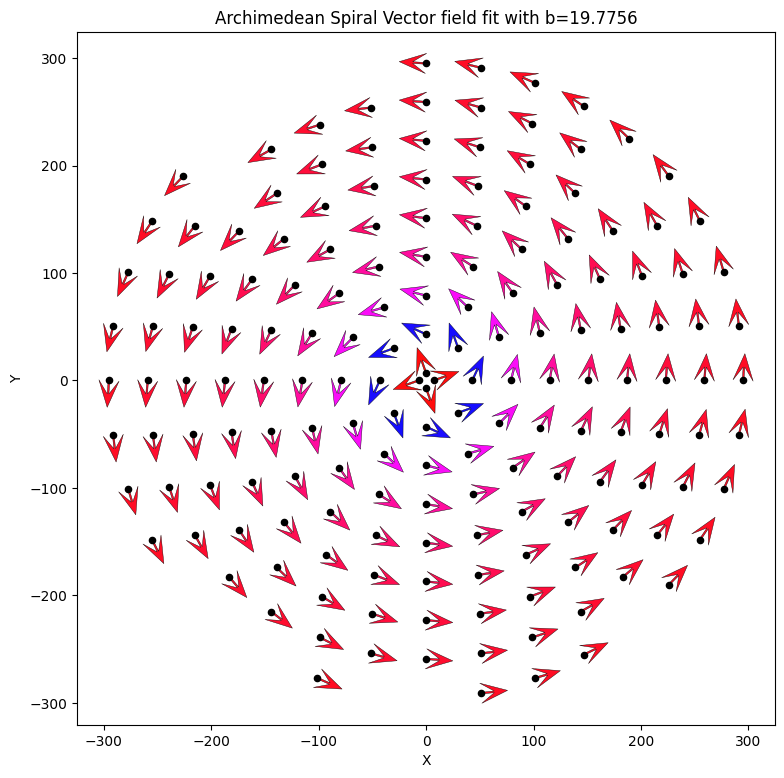

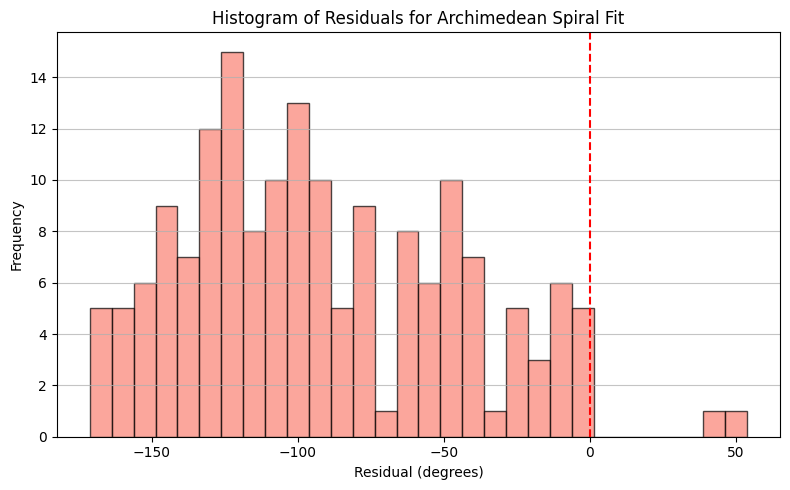

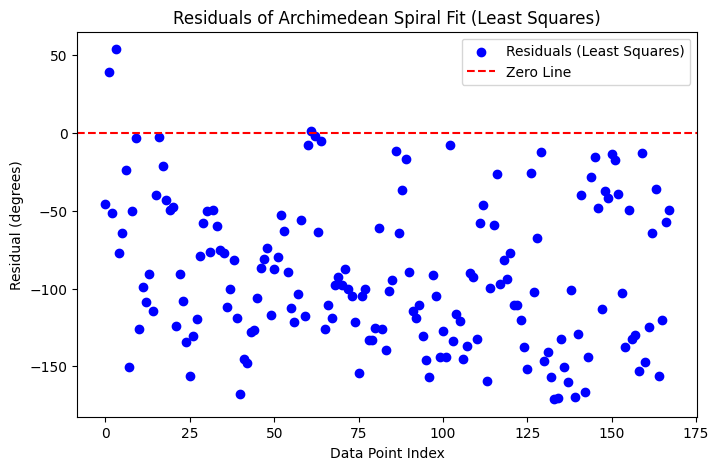

In [24]:
# Case 2: Archimedean Spiral
## Solve the least squares problem to fit spirals
def objective_archimedean_spiral(b, angles, r, scaling = True):
    predicted_angles = np.degrees(np.arctan(r / b))
    if scaling:
        residuals = np.sqrt(r**2 + b**2)/r * (angles - predicted_angles)
    else:
        residuals = angles - predicted_angles
    # residuals = angles - predicted_angles
    return np.sum(residuals**2)

def objective_archimedean_spiral_sin(b, angles, r, scaling = True):
    if scaling == True: 
        residuals = np.sqrt(r**2 + b**2)/r * np.sin(np.deg2rad(angles - np.degrees(np.arctan(r / b))))
    predicted_angles = np.degrees(np.arctan(r / b))
    residuals = np.sin(np.deg2rad(angles - predicted_angles))
    return np.sum(residuals**2)

# Initial guess for b
b0 = 1.0
# Optimize using the objective function
result5 = minimize(objective_archimedean_spiral, b0, args=(angles_deg, r))
b_opt1 = result5.x[0]
# Optimize using the sin squared objective function
result6 = minimize(objective_archimedean_spiral_sin, b0, args=(angles_deg, r))
b_opt2 = result6.x[0]
print(f"Optimized b (least squares): {b_opt1:.4f}")
print(f"Optimized b (sin squared): {b_opt2:.4f}")
print(result5)
print(result6)

## Plot the vector field with the fitted Archimedean spirals and their residuals
predicted_angles_archimedean = np.degrees(np.arctan(r / b_opt1))
residuals_archimedean = angles_deg - predicted_angles_archimedean
# For each x_i, y_i coordinate, compute the predicted vector from the fitted spiral
for i in range(len(coordinates)):
    r_i = r[i]
    theta_i = theta[i]
    fitted_angle = predicted_angles_archimedean[i]
    phi_fitted = fitted_angle + np.degrees(theta_i)
    phi_fitted_rad = np.deg2rad(phi_fitted)
    U_fitted = np.cos(phi_fitted_rad)
    V_fitted = np.sin(phi_fitted_rad)

plt.figure(figsize=(9, 9))
U_fitted_scaled = magnitude_scale * np.cos(np.deg2rad(predicted_angles_archimedean + np.degrees(theta)))
V_fitted_scaled = magnitude_scale * np.sin(np.deg2rad(predicted_angles_archimedean + np.degrees(theta)))
q_fitted = plt.quiver(
    X, Y, U_fitted_scaled, V_fitted_scaled, predicted_angles_archimedean,
    angles='xy', scale_units='xy', scale=1, cmap='hsv',
    width=0.015,
    headwidth=12,
    headlength=16,
    headaxislength=8,
    alpha=0.95, edgecolor='k', linewidth=0.3
)   
plt.scatter(X, Y, c='k', s=20, zorder=3)
plt.gca().set_aspect('equal', 'box')
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Archimedean Spiral Vector field fit with b={b_opt1:.4f}')
plt.show()

## Plot residuals histogram for Archimedean spiral fit
plt.figure(figsize=(8, 5))
plt.hist(residuals_archimedean, bins=30, color='salmon', edgecolor='black', alpha=0.7)
plt.axvline(0, color='red', linestyle='--', label='Zero Line')

plt.title('Histogram of Residuals for Archimedean Spiral Fit')
plt.xlabel('Residual (degrees)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()
plt.figure(figsize=(8, 5))
plt.scatter(range(len(residuals_archimedean)), residuals_archimedean, color='blue', label='Residuals (Least Squares)')
plt.axhline(0, color='red', linestyle='--', label='Zero Line')
plt.xlabel('Data Point Index')
plt.ylabel('Residual (degrees)')
plt.title('Residuals of Archimedean Spiral Fit (Least Squares)')
plt.legend()


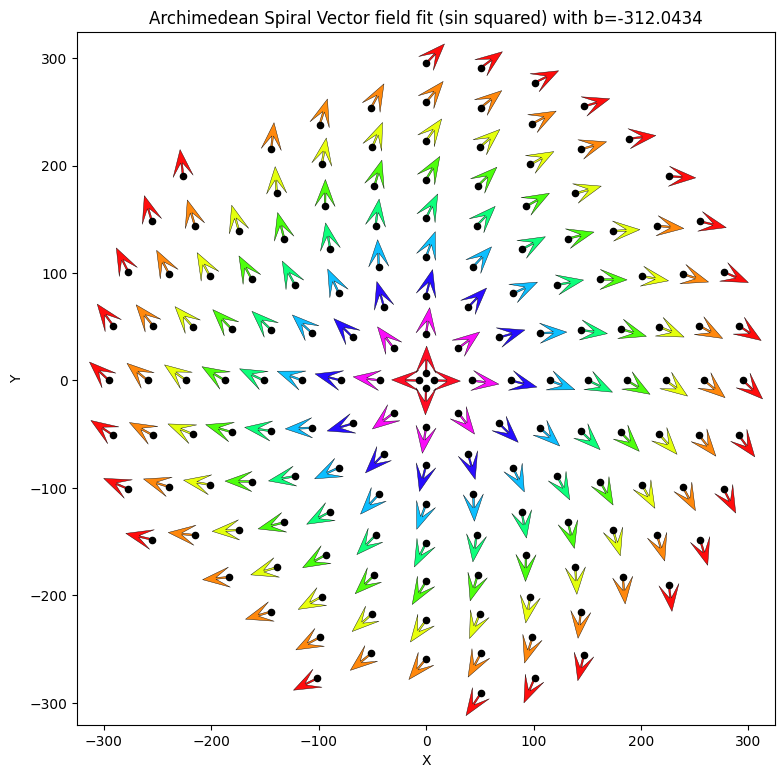

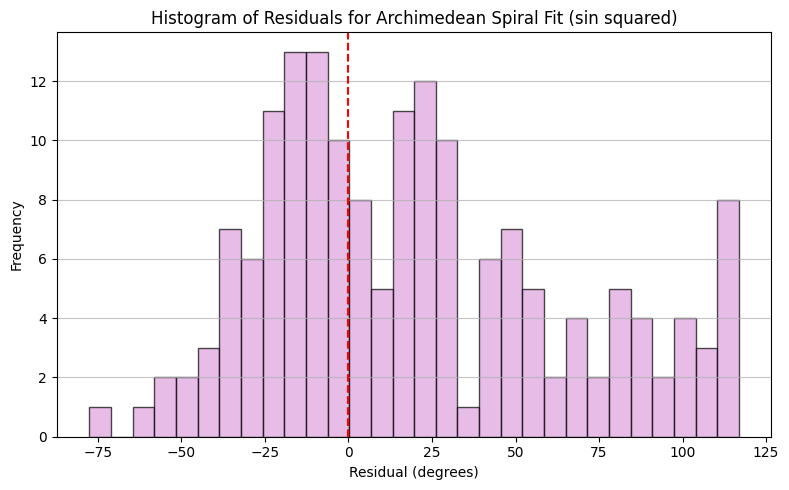

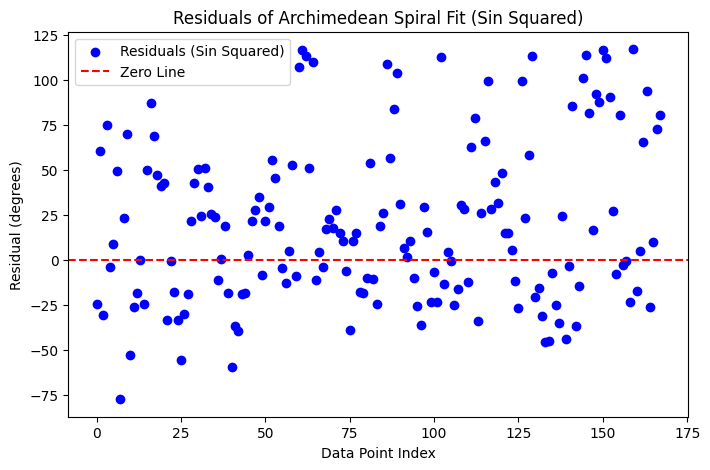

In [25]:
# Plot predicted vector field for Archimedean spiral (sin squared)
predicted_angles_archimedean2 = np.degrees(np.arctan(r / b_opt2))
residuals_archimedean2 = angles_deg - predicted_angles_archimedean2
plt.figure(figsize=(9, 9))
U_fitted_scaled2 = magnitude_scale * np.cos(np.deg2rad(predicted_angles_archimedean2 + np.degrees(theta)))
V_fitted_scaled2 = magnitude_scale * np.sin(np.deg2rad(predicted_angles_archimedean2 + np.degrees(theta)))
q_fitted2 = plt.quiver(
    X, Y, U_fitted_scaled2, V_fitted_scaled2, predicted_angles_archimedean2,
    angles='xy', scale_units='xy', scale=1, cmap='hsv',
    width=0.015,
    headwidth=12,
    headlength=16,
    headaxislength=8,
    alpha=0.95, edgecolor='k', linewidth=0.3
)
plt.scatter(X, Y, c='k', s=20, zorder=3)
plt.gca().set_aspect('equal', 'box')
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Archimedean Spiral Vector field fit (sin squared) with b={b_opt2:.4f}')
plt.show()  

# plot residuals histogram for Archimedean spiral fit (sin squared)
plt.figure(figsize=(8, 5))
plt.hist(residuals_archimedean2, bins=30, color='plum', edgecolor='black', alpha=0.7)
plt.axvline(0, color='red', linestyle='--', label='Zero Line')
plt.title('Histogram of Residuals for Archimedean Spiral Fit (sin squared)')
plt.xlabel('Residual (degrees)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()
plt.figure(figsize=(8, 5))
plt.scatter(range(len(residuals_archimedean2)), residuals_archimedean2, color='blue', label='Residuals (Sin Squared)')
plt.axhline(0, color='red', linestyle='--', label='Zero Line')
plt.xlabel('Data Point Index')
plt.ylabel('Residual (degrees)')
plt.title('Residuals of Archimedean Spiral Fit (Sin Squared)')
plt.legend()


In [26]:
# Case 3: Fermat Spiral
## Solve the least squares problem to fit spirals

def objective_fermat_spiral(a, angles, r, scaling = True):
    predicted_angles = np.degrees(np.arctan(2 * r**2 / a**2))
    if scaling:
        residuals = np.sqrt(4 * r**4 + a**4)/r * (angles - predicted_angles)
    else:
        residuals = angles - predicted_angles
    return np.sum(residuals**2)

def objective_fermat_spiral_sin(a, angles, r, scaling = True):
    if scaling == True: 
        residuals = np.sqrt(4 * r**4 + a**4)/r * np.sin(np.deg2rad(angles - np.degrees(np.arctan(2 * r**2 / a**2))))
    else:
        residuals = np.sin(np.deg2rad(angles - np.degrees(np.arctan(2 * r**2 / a**2))))
    return np.sum(residuals**2)

# Initial guess for a
a0 = 1.0
# Optimize using the objective function
result3 = minimize(objective_fermat_spiral, a0, args=(angles_deg, r))
a_opt1 = result3.x[0]
# Optimize using the sin squared objective function
result4 = minimize(objective_fermat_spiral_sin, a0, args=(angles_deg, r))
a_opt2 = result4.x[0]
print(f"Optimized a (least squares): {a_opt1:.4f}")
print(f"Optimized a (sin squared): {a_opt2:.4f}")
print(result3)
print(result4)

Optimized a (least squares): 78.0219
Optimized a (sin squared): -0.0004
  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 348727712086.3609
        x: [ 7.802e+01]
      nit: 4
      jac: [ 0.000e+00]
 hess_inv: [[ 7.425e-08]]
     nfev: 22
     njev: 11
  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 15305236.138930889
        x: [-3.803e-04]
      nit: 3
      jac: [ 0.000e+00]
 hess_inv: [[ 6.413e-03]]
     nfev: 8
     njev: 4


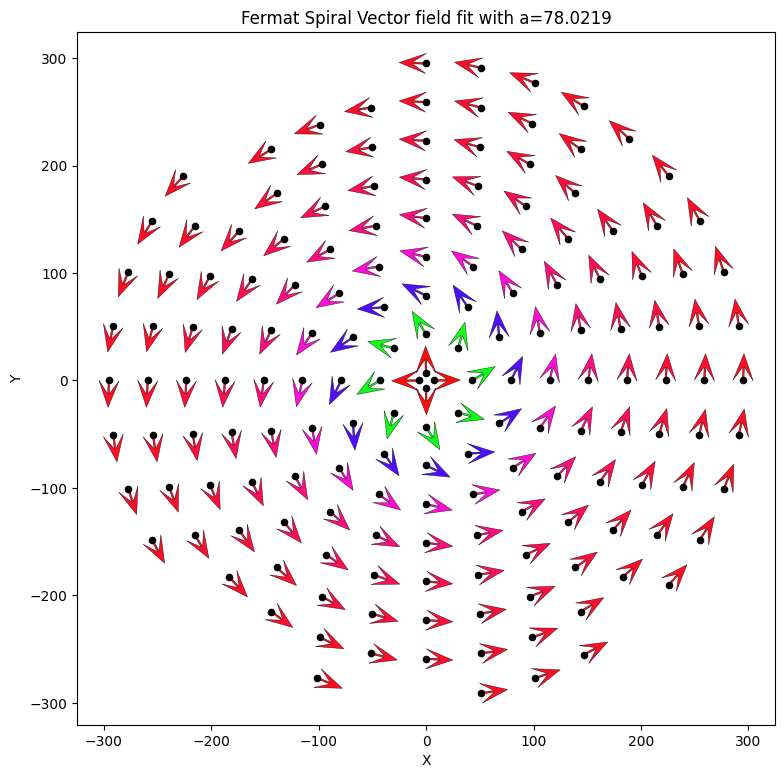

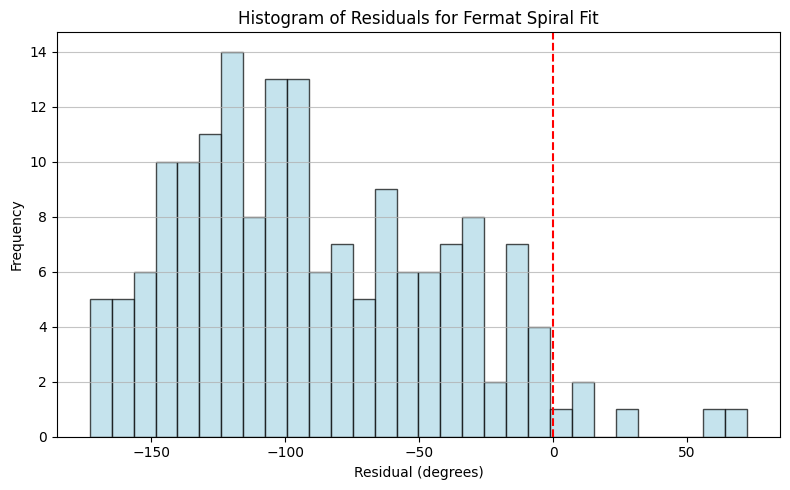

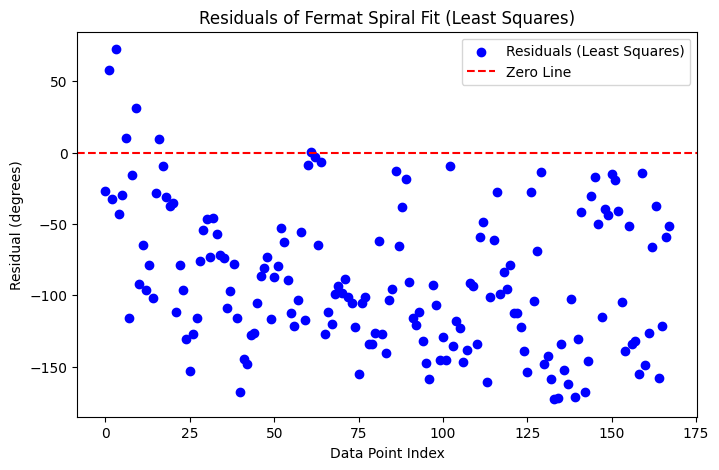

In [27]:
## plot the vector field with the fitted Fermat spirals and their residuals
predicted_angles_fermat = np.degrees(np.arctan(2 * r**2 / a_opt1**2))
residuals_fermat = angles_deg - predicted_angles_fermat
# For each x_i, y_i coordinate, compute the predicted vector from the fitted spiral
for i in range(len(coordinates)):
    r_i = r[i]
    theta_i = theta[i]
    fitted_angle = predicted_angles_fermat[i]
    phi_fitted = fitted_angle + np.degrees(theta_i)
    phi_fitted_rad = np.deg2rad(phi_fitted)
    U_fitted = np.cos(phi_fitted_rad)
    V_fitted = np.sin(phi_fitted_rad)
plt.figure(figsize=(9, 9))
U_fitted_scaled = magnitude_scale * np.cos(np.deg2rad(predicted_angles_fermat + np.degrees(theta)))
V_fitted_scaled = magnitude_scale * np.sin(np.deg2rad(predicted_angles_fermat + np.degrees(theta)))
q_fitted = plt.quiver(
    X, Y, U_fitted_scaled, V_fitted_scaled, predicted_angles_fermat,
    angles='xy', scale_units='xy', scale=1, cmap='hsv',
    width=0.015,
    headwidth=12,
    headlength=16,
    headaxislength=8,
    alpha=0.95, edgecolor='k', linewidth=0.3
)
plt.scatter(X, Y, c='k', s=20, zorder=3)
plt.gca().set_aspect('equal', 'box')
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Fermat Spiral Vector field fit with a={a_opt1:.4f}')
plt.show()  

## Plot residuals histogram for Fermat spiral fit
plt.figure(figsize=(8, 5))
plt.hist(residuals_fermat, bins=30, color='lightblue', edgecolor='black', alpha=0.7)
plt.axvline(0, color='red', linestyle='--', label='Zero Line')
plt.title('Histogram of Residuals for Fermat Spiral Fit')
plt.xlabel('Residual (degrees)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()
plt.figure(figsize=(8, 5))
plt.scatter(range(len(residuals_fermat)), residuals_fermat, color='blue', label='Residuals (Least Squares)')
plt.axhline(0, color='red', linestyle='--', label='Zero Line')
plt.xlabel('Data Point Index')
plt.ylabel('Residual (degrees)')
plt.title('Residuals of Fermat Spiral Fit (Least Squares)')
plt.legend()


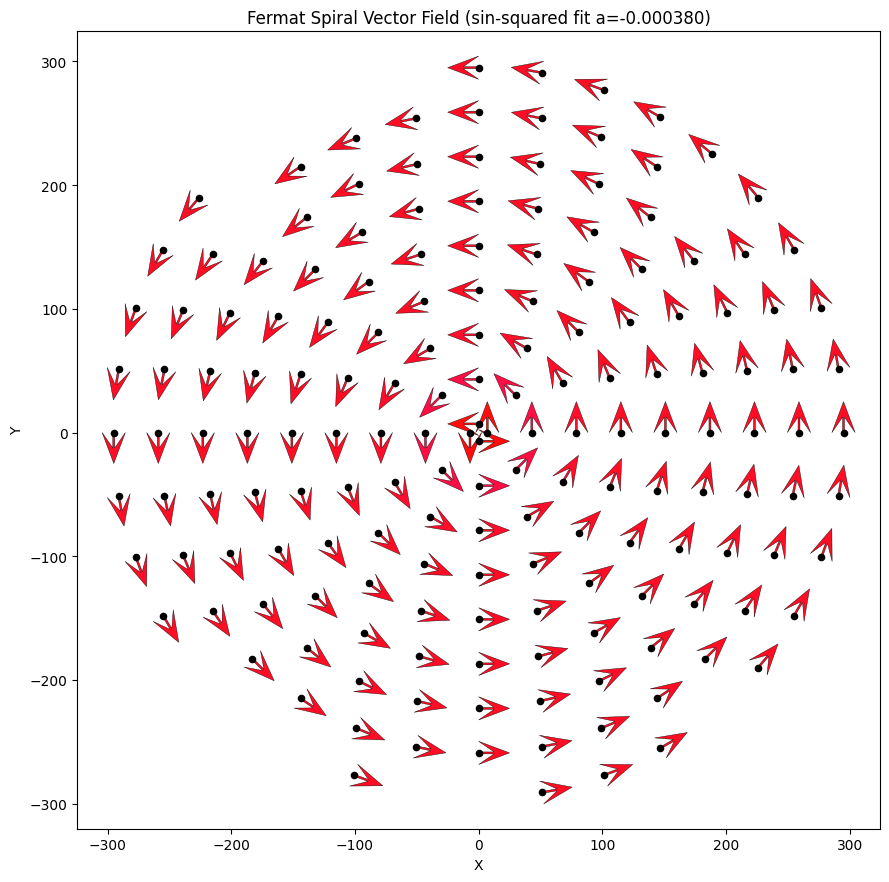

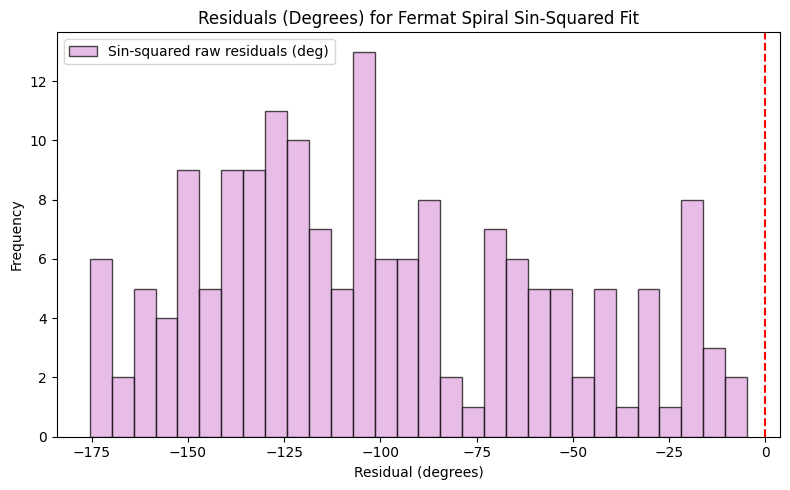

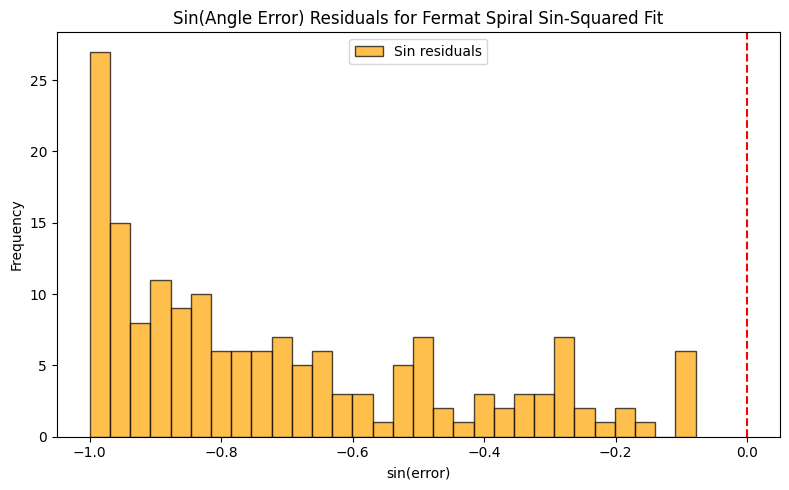

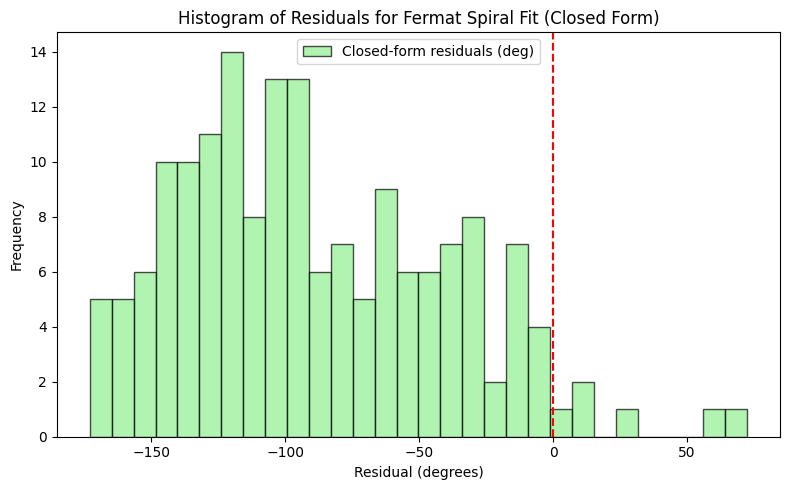

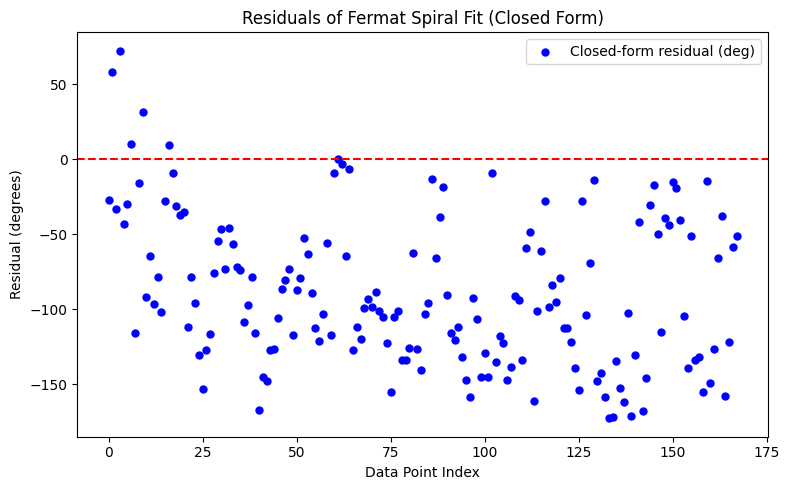

In [28]:
## Plot the vector field with the fitted Fermat spiral (sin-squared objective)
## Use a_opt2 from the sin-squared fit and keep original least-squares results intact.
eps = 1e-12
predicted_angles_fermat_sin = np.degrees(np.arctan(2 * r**2 / (a_opt2**2 + eps)))
# raw angular residuals (degrees) and sin-based residuals
residuals_fermat_sin_deg = angles_deg - predicted_angles_fermat_sin
residuals_fermat_sin = np.sin(np.deg2rad(residuals_fermat_sin_deg))

# Vector field construction for sin-squared fit (do not overwrite previously defined predicted_angles_fermat)
plt.figure(figsize=(9, 9))
U_fitted_scaled_sin = magnitude_scale * np.cos(np.deg2rad(predicted_angles_fermat_sin + np.degrees(theta)))
V_fitted_scaled_sin = magnitude_scale * np.sin(np.deg2rad(predicted_angles_fermat_sin + np.degrees(theta)))
q_fitted_sin = plt.quiver(
    X, Y, U_fitted_scaled_sin, V_fitted_scaled_sin, predicted_angles_fermat_sin,
    angles='xy', scale_units='xy', scale=1, cmap='hsv',
    width=0.015,
    headwidth=12,
    headlength=16,
    headaxislength=8,
    alpha=0.95, edgecolor='k', linewidth=0.3
)
plt.scatter(X, Y, c='k', s=20, zorder=3)
plt.gca().set_aspect('equal', 'box')
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Fermat Spiral Vector Field (sin-squared fit a={a_opt2:.6f})')
plt.tight_layout()
plt.show()

# Closed-form (least-squares) angles retained for comparison (a_opt1)
predicted_angles_closed = np.degrees(np.arctan(2 * r**2 / (a_opt1**2 + eps)))
residuals_closed = angles_deg - predicted_angles_closed

# Histograms of residuals
plt.figure(figsize=(8, 5))
plt.hist(residuals_fermat_sin_deg, bins=30, color='plum', edgecolor='black', alpha=0.7, label='Sin-squared raw residuals (deg)')
plt.axvline(0, color='red', linestyle='--')
plt.title('Residuals (Degrees) for Fermat Spiral Sin-Squared Fit')
plt.xlabel('Residual (degrees)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(residuals_fermat_sin, bins=30, color='orange', edgecolor='black', alpha=0.7, label='Sin residuals')
plt.axvline(0, color='red', linestyle='--')
plt.title('Sin(Angle Error) Residuals for Fermat Spiral Sin-Squared Fit')
plt.xlabel('sin(error)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

# Closed-form residuals histogram (least-squares)
plt.figure(figsize=(8, 5))
plt.hist(residuals_closed, bins=30, color='lightgreen', edgecolor='black', alpha=0.7, label='Closed-form residuals (deg)')
plt.axvline(0, color='red', linestyle='--')
plt.title('Histogram of Residuals for Fermat Spiral Fit (Closed Form)')
plt.xlabel('Residual (degrees)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

# Scatter of closed-form residuals
plt.figure(figsize=(8, 5))
plt.scatter(range(len(residuals_closed)), residuals_closed, color='blue', s=25, label='Closed-form residual (deg)')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Data Point Index')
plt.ylabel('Residual (degrees)')
plt.title('Residuals of Fermat Spiral Fit (Closed Form)')
plt.legend()
plt.tight_layout()
plt.show()

## TODO
1. Write down the necessary theorems and proofs for the above problem at hand, and possibly use it as an example to motivate directional statistics
2. Change the residual information from a vector field to a line field. The reflective symmetry, as that of $\sin^2(x)$ should be reflected in the plots.
3. Use likelihoods / Bayes factors to compare between models.

In [ ]:
## Finding the parametric family of spiral vectors with $p$ as a parameter
def g_p(r, p):
    if p == 0:
        return np.log(r + 1e-8)  # add small value to avoid log(0)
    else:
        return r**p / p

def minimize_spiral_parametric(params, angles, r):
    A, b, p = params
    # Compute predicted angles based on the parametric spiral model
    def g_p(r, p):
        if p == 0:
            return np.log(r + 1e-8)  # add small value to avoid log(0)
        else:
            return r**p / p
    predicted_angles = np.degrees(np.arctan(A * g_p(r, p) / b))
    residuals = angles - predicted_angles
    return np.sum(residuals**2)



